# PM2.5 Autoregressive Model - Data Preparation & Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## 1. Data Loading & Coverage Analysis

In [2]:
df = pd.read_csv('../../data/pm25_enriched_hourly_2023_20250826_004834.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Unique hexagons: {df['hex7_id'].nunique()}")

Dataset shape: (2049356, 17)
Date range: 2023-07-14 16:00:00+00:00 to 2023-12-31 23:00:00+00:00
Unique hexagons: 629


In [3]:
coverage_stats = df.groupby('hex7_id').agg({
    'pm25_ugm3_mean': ['count', lambda x: x.notna().sum(), lambda x: x.notna().mean()]
}).round(3)

coverage_stats.columns = ['total_hours', 'valid_pm25', 'coverage_ratio']
coverage_stats['missing_hours'] = coverage_stats['total_hours'] - coverage_stats['valid_pm25']

print(f"\nFull Dataset Coverage Summary:")
print(coverage_stats.describe())


Full Dataset Coverage Summary:
       total_hours  valid_pm25  coverage_ratio  missing_hours
count      629.000     629.000         629.000        629.000
mean      2585.038    2585.038           0.789          0.000
std       1257.449    1257.449           0.364          0.000
min          0.000       0.000           0.000          0.000
25%       2279.000    2279.000           0.869          0.000
50%       3272.000    3272.000           0.968          0.000
75%       3367.000    3367.000           0.987          0.000
max       3460.000    3460.000           1.000          0.000


## 2. H3 Resolution Analysis

In [4]:
def aggregate_to_resolution(df, target_resolution):
    df_agg = df.copy()
    df_agg['parent_hex'] = df_agg['hex7_id'].apply(lambda x: h3.cell_to_parent(x, target_resolution))
    
    result = df_agg.groupby(['timestamp', 'parent_hex']).agg({
        'pm25_ugm3_mean': ['mean', 'std', 'count', lambda x: x.notna().mean()]
    }).reset_index()
    
    result.columns = ['timestamp', 'hex_id', 'pm25_mean', 'pm25_std', 'sensor_count', 'coverage']
    result['resolution'] = target_resolution
    
    return result

resolutions = {}
for res in [7, 6, 5]:
    resolutions[res] = aggregate_to_resolution(df, res)
    coverage = resolutions[res].groupby('hex_id')['coverage'].mean().mean()
    hexagons = resolutions[res]['hex_id'].nunique()
    print(f"Resolution {res}: {hexagons} hexagons, {coverage:.1%} avg coverage")

Resolution 7: 629 hexagons, 78.9% avg coverage
Resolution 6: 544 hexagons, 79.3% avg coverage
Resolution 5: 351 hexagons, 79.2% avg coverage


## 3. Tokyo Focus Analysis

In [5]:
TOKYO_BOUNDS = {
    'lat_min': 35.5, 'lat_max': 35.9,
    'lon_min': 139.5, 'lon_max': 140.0
}

res7_data = resolutions[7]

res7_with_coords = res7_data.copy()
res7_with_coords['lat'] = res7_with_coords['hex_id'].apply(lambda x: h3.cell_to_latlng(x)[0])
res7_with_coords['lon'] = res7_with_coords['hex_id'].apply(lambda x: h3.cell_to_latlng(x)[1])

tokyo_data = res7_with_coords[
    (res7_with_coords['lat'] >= TOKYO_BOUNDS['lat_min']) &
    (res7_with_coords['lat'] <= TOKYO_BOUNDS['lat_max']) &
    (res7_with_coords['lon'] >= TOKYO_BOUNDS['lon_min']) &
    (res7_with_coords['lon'] <= TOKYO_BOUNDS['lon_max'])
]

tokyo_wide = tokyo_data.pivot_table(
    index='timestamp',
    columns='hex_id',
    values='pm25_mean'
)

print(f"Tokyo area: {tokyo_wide.shape[1]} hexagons, {tokyo_wide.shape[0]} hours")
print(f"Data completeness: {tokyo_wide.notna().mean().mean():.1%}")
print(f"Date range: {tokyo_wide.index.min()} to {tokyo_wide.index.max()}")

Tokyo area: 53 hexagons, 3466 hours
Data completeness: 95.8%
Date range: 2023-07-14 16:00:00+00:00 to 2023-12-31 23:00:00+00:00


## 4. Time Series Feature Engineering

In [6]:
def create_features(series, hex_id):
    df = pd.DataFrame({'pm25': series})
    df['hexagon'] = hex_id
    
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'lag_{lag}h'] = df['pm25'].shift(lag)
    
    df['rolling_mean_6h'] = df['pm25'].rolling(6, min_periods=1).mean()
    df['rolling_std_6h'] = df['pm25'].rolling(6, min_periods=1).std()
    df['rolling_mean_24h'] = df['pm25'].rolling(24, min_periods=1).mean()
    
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

high_coverage_hexagons = tokyo_wide.columns[tokyo_wide.notna().mean() > 0.8]
print(f"Processing {len(high_coverage_hexagons)} high coverage hexagons")

featured_data = []
for hex_id in high_coverage_hexagons[:10]:
    hex_features = create_features(tokyo_wide[hex_id], hex_id)
    featured_data.append(hex_features)

featured_df = pd.concat(featured_data, ignore_index=True)

Processing 53 high coverage hexagons


## 5. Autocorrelation Analysis

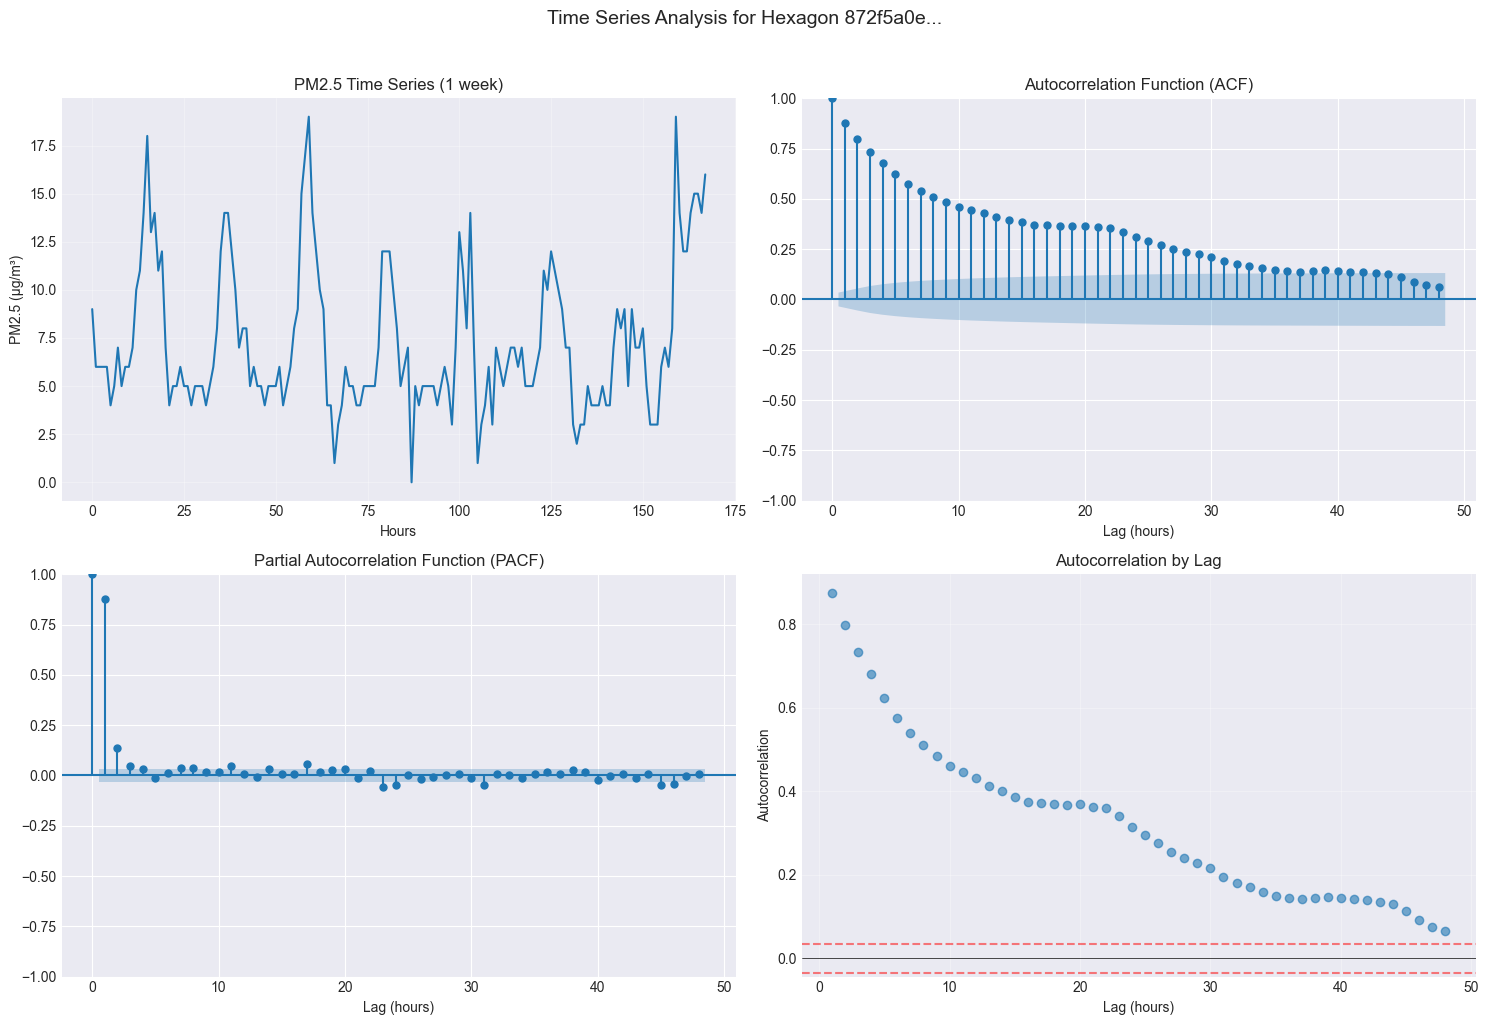


Key observations:
ACF at 24h lag: 0.315
ACF at 12h lag: 0.431
ACF at 6h lag: 0.576
ACF at 1h lag: 0.876


In [7]:
sample_hex = high_coverage_hexagons[0]
sample_series = tokyo_wide[sample_hex].dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(sample_series.values[:168])
axes[0, 0].set_title('PM2.5 Time Series (1 week)', fontsize=12)
axes[0, 0].set_xlabel('Hours')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].grid(True, alpha=0.3)

plot_acf(sample_series.values, lags=48, ax=axes[0, 1])
axes[0, 1].set_title('Autocorrelation Function (ACF)', fontsize=12)
axes[0, 1].set_xlabel('Lag (hours)')

plot_pacf(sample_series.values, lags=48, ax=axes[1, 0])
axes[1, 0].set_title('Partial Autocorrelation Function (PACF)', fontsize=12)
axes[1, 0].set_xlabel('Lag (hours)')

autocorr_values = [sample_series.autocorr(lag=i) for i in range(1, 49)]
axes[1, 1].scatter(range(1, 49), autocorr_values, alpha=0.6)
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=1.96/np.sqrt(len(sample_series)), color='r', linestyle='--', alpha=0.5)
axes[1, 1].axhline(y=-1.96/np.sqrt(len(sample_series)), color='r', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Autocorrelation by Lag', fontsize=12)
axes[1, 1].set_xlabel('Lag (hours)')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Time Series Analysis for Hexagon {sample_hex[:8]}...', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nKey observations:")
print(f"ACF at 24h lag: {sample_series.autocorr(lag=24):.3f}")
print(f"ACF at 12h lag: {sample_series.autocorr(lag=12):.3f}")
print(f"ACF at 6h lag: {sample_series.autocorr(lag=6):.3f}")
print(f"ACF at 1h lag: {sample_series.autocorr(lag=1):.3f}")

In [8]:
def create_features(series, hex_id):
    df = pd.DataFrame({'pm25': series})
    df['hexagon'] = hex_id
    df['timestamp'] = df.index
    
    for lag in [1, 2, 3, 4, 5, 6, 12, 24]:
        df[f'lag_{lag}h'] = df['pm25'].shift(lag)
    
    df['rolling_mean_6h'] = df['pm25'].rolling(6, min_periods=1).mean()
    df['rolling_std_6h'] = df['pm25'].rolling(6, min_periods=1).std()
    df['rolling_mean_24h'] = df['pm25'].rolling(24, min_periods=1).mean()
    
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

high_coverage_hexagons = tokyo_wide.columns[tokyo_wide.notna().mean() > 0.8]
print(f"Processing {len(high_coverage_hexagons)} high coverage hexagons")

featured_data = []
for hex_id in high_coverage_hexagons[:10]:
    hex_features = create_features(tokyo_wide[hex_id], hex_id)
    featured_data.append(hex_features)

featured_df = pd.concat(featured_data, ignore_index=True)

Processing 53 high coverage hexagons


## 6. Multi-Horizon Target Creation

In [9]:
ml_datasets = []

for hex_id in high_coverage_hexagons[:10]:
    hex_data = featured_df[featured_df['hexagon'] == hex_id].copy()
    
    for h in [1, 2, 3, 4, 5, 6, 12, 24]:
        hex_data[f'target_h{h}'] = hex_data['pm25'].shift(-h)
    
    ml_datasets.append(hex_data)

ml_dataset = pd.concat(ml_datasets, ignore_index=True)
ml_dataset = ml_dataset.dropna()

print(f"ML dataset: {ml_dataset.shape[0]} samples, {ml_dataset.shape[1]} features")

ML dataset: 27882 samples, 29 features


## 7. Train/Val/Test Split

In [10]:
ml_dataset = ml_dataset.sort_values('timestamp').reset_index(drop=True)

unique_timestamps = ml_dataset['timestamp'].unique()
n_timestamps = len(unique_timestamps)

train_end_idx = int(0.7 * n_timestamps)
val_end_idx = int(0.85 * n_timestamps)

train_end_time = unique_timestamps[train_end_idx]
val_end_time = unique_timestamps[val_end_idx]

train = ml_dataset[ml_dataset['timestamp'] < train_end_time].copy()
val = ml_dataset[(ml_dataset['timestamp'] >= train_end_time) & (ml_dataset['timestamp'] < val_end_time)].copy()
test = ml_dataset[ml_dataset['timestamp'] >= val_end_time].copy()

print(f"Train: {len(train):,} samples")
print(f"Val: {len(val):,} samples")
print(f"Test: {len(test):,} samples")
print(f"\nTrain period: {train['timestamp'].min()} to {train['timestamp'].max()}")
print(f"Val period: {val['timestamp'].min()} to {val['timestamp'].max()}")
print(f"Test period: {test['timestamp'].min()} to {test['timestamp'].max()}")

Train: 20,588 samples
Val: 3,643 samples
Test: 3,651 samples

Train period: 2023-07-28 10:00:00+00:00 to 2023-11-14 03:00:00+00:00
Val period: 2023-11-14 04:00:00+00:00 to 2023-12-07 09:00:00+00:00
Test period: 2023-12-07 10:00:00+00:00 to 2023-12-30 21:00:00+00:00


## 8. Export for Modeling

In [11]:
feature_cols = [c for c in train.columns if c not in ['target_h1', 'target_h2', 'target_h3', 'target_h4', 
                                                        'target_h5', 'target_h6', 'target_h12', 'target_h24',
                                                        'hexagon', 'timestamp', 'pm25']]

X_train = train[feature_cols]
y_train = train['target_h1']
X_test = test[feature_cols]
y_test = test['target_h1']

print(f"Features used: {len(feature_cols)}")
print(f"Sample features: {feature_cols[:5]}")

persistence_pred = X_test['lag_1h'].values
persistence_mae = mean_absolute_error(y_test, persistence_pred)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)

print(f"\nPersistence MAE: {persistence_mae:.3f}")
print(f"Linear Regression MAE: {lr_mae:.3f}")
print(f"Improvement: {(persistence_mae - lr_mae)/persistence_mae*100:.1f}%")

Features used: 18
Sample features: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_5h']

Persistence MAE: 3.283
Linear Regression MAE: 2.379
Improvement: 27.5%


## 9. Advanced Models with Multi-Horizon Forecasting

In [12]:
feature_cols = [c for c in train.columns if c not in ['target_h1', 'target_h2', 'target_h3', 'target_h4', 
                                                        'target_h5', 'target_h6', 'target_h12', 'target_h24',
                                                        'hexagon', 'timestamp', 'pm25']]

X_train = train[feature_cols]
X_test = test[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

horizons = [1, 2, 3, 4, 5, 6, 12, 24]
models = {
    'Persistence': None,
    'LinearReg': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42)
}

results = []

for h in horizons:
    target_col = f'target_h{h}'
    
    if target_col not in train.columns:
        continue
        
    y_train_h = train[target_col]
    y_test_h = test[target_col]
    
    for model_name, model in models.items():
        if model_name == 'Persistence':
            lag_col = f'lag_{h}h' if f'lag_{h}h' in X_test.columns else 'lag_1h'
            predictions = X_test[lag_col].values
        else:
            if model_name in ['Ridge']:
                model.fit(X_train_scaled, y_train_h)
                predictions = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train_h)
                predictions = model.predict(X_test)
        
        mae = mean_absolute_error(y_test_h, predictions)
        rmse = np.sqrt(mean_squared_error(y_test_h, predictions))
        r2 = r2_score(y_test_h, predictions)
        
        results.append({
            'Horizon': f'{h}h',
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

results_df = pd.DataFrame(results)

pivot_mae = results_df.pivot_table(index='Model', columns='Horizon', values='MAE')
pivot_mae = pivot_mae[[f'{h}h' for h in horizons if f'{h}h' in pivot_mae.columns]]

pivot_r2 = results_df.pivot_table(index='Model', columns='Horizon', values='R2')
pivot_r2 = pivot_r2[[f'{h}h' for h in horizons if f'{h}h' in pivot_r2.columns]]

print("\nMAE by Model and Horizon (μg/m³):")
print(pivot_mae.round(2))

print("\nR² by Model and Horizon:")
print(pivot_r2.round(3))

print("\nExpected pattern: R² should decrease as horizon increases")
for model in ['LinearReg', 'RandomForest']:
    r2_values = [pivot_r2.loc[model, f'{h}h'] for h in horizons if f'{h}h' in pivot_r2.columns]
    print(f"{model}: {' > '.join([f'{v:.3f}' for v in r2_values])}")

best_models = results_df.loc[results_df.groupby('Horizon')['MAE'].idxmin()]
print("\nBest Model per Horizon (by MAE):")
print(best_models[['Horizon', 'Model', 'MAE', 'R2']].to_string(index=False))


MAE by Model and Horizon (μg/m³):
Horizon             1h    2h    3h    4h    5h    6h   12h   24h
Model                                                           
GradientBoosting 3.070 3.800 4.230 4.690 4.850 5.090 5.830 7.370
LinearReg        2.380 3.130 3.650 4.010 4.250 4.470 5.060 6.170
Persistence      3.280 4.450 5.020 5.330 5.460 5.690 7.150 9.560
RandomForest     3.120 4.000 4.480 4.750 5.070 5.230 6.050 7.290
Ridge            2.380 3.140 3.650 4.010 4.250 4.470 5.060 6.170

R² by Model and Horizon:
Horizon             1h    2h    3h     4h     5h     6h    12h    24h
Model                                                                
GradientBoosting 0.626 0.445 0.322  0.198  0.143  0.069 -0.152 -0.655
LinearReg        0.772 0.612 0.485  0.392  0.323  0.270  0.103 -0.109
Persistence      0.560 0.224 0.024 -0.065 -0.103 -0.162 -0.657 -1.563
RandomForest     0.612 0.373 0.228  0.155  0.053  0.015 -0.304 -0.639
Ridge            0.772 0.612 0.485  0.392  0.323  0.270  0.103 -